In [1]:
#ml r/4.2.2-py310-ly4mhww
#R RHOME
%env R_HOME=/opt/rit/el9/20230413/app/linux-rhel9-x86_64_v3/gcc-11.2.1/r-4.2.2-ly4mhww3hc75wzv4bygq2oisiochvsq4/rlib/R
#%env R_HOME=/work/ABG/mkapoor/micromamba/envs/muscat/lib/R/library
#pandas.__version__

env: R_HOME=/opt/rit/el9/20230413/app/linux-rhel9-x86_64_v3/gcc-11.2.1/r-4.2.2-ly4mhww3hc75wzv4bygq2oisiochvsq4/rlib/R


In [2]:
import os
import numpy as np
import scanorama
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import pandas as pd
import pickle
from pandas import Index
# from pandas import PandasIndex
import anndata as ad
import scipy
import anndata2ri
anndata2ri.scipy2ri.activate()
import logging
import rpy2
from rpy2.robjects import pandas2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
#pandas.__version__
from plotnine import (
    ggplot, aes, geom_histogram, scale_x_continuous, facet_wrap, geom_vline,
    theme, element_text, labs, ylim
)

/tmp/ipykernel_534740/1168514264.py:15: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.scipy2ri.activate()


In [3]:
os.chdir("/work/ABG/mkapoor/mkapoor/Project_Fang_10X/14dpi_PRRSV/Project_Fang_10X/Project_Fang_10X")
sample_dirs = [d for d in os.listdir() if d.startswith('Sample_') and os.path.isdir(d)]
sample_dirs
cellbender_output =  []
metrics_files = []
for sample_dir in sample_dirs:
    files = os.listdir(sample_dir)
    sample_dir_path = os.path.join(sample_dir, f"{sample_dir}_cb_10k")
    if os.path.exists(sample_dir_path):
        files = os.listdir(sample_dir_path)
        metrics = [os.path.join(sample_dir_path, f) for f in files if f.endswith('metrics.csv')]
        filtered_files = [os.path.join(sample_dir_path, f) for f in files if f.endswith('10k_filtered.h5')]
        cellbender_output.extend(filtered_files)
        metrics_files.extend(metrics)

In [4]:
cellbender_output

['Sample_64/Sample_64_cb_10k/Sample_64_cb_10k_filtered.h5',
 'Sample_4/Sample_4_cb_10k/Sample_4_cb_10k_filtered.h5',
 'Sample_3/Sample_3_cb_10k/Sample_3_cb_10k_filtered.h5',
 'Sample_35/Sample_35_cb_10k/Sample_35_cb_10k_filtered.h5',
 'Sample_102/Sample_102_cb_10k/Sample_102_cb_10k_filtered.h5',
 'Sample_5/Sample_5_cb_10k/Sample_5_cb_10k_filtered.h5',
 'Sample_33/Sample_33_cb_10k/Sample_33_cb_10k_filtered.h5',
 'Sample_101/Sample_101_cb_10k/Sample_101_cb_10k_filtered.h5',
 'Sample_66/Sample_66_cb_10k/Sample_66_cb_10k_filtered.h5']

In [19]:
import h5py
bc = "TAACGACGTACGTAGG-1"
with h5py.File('/work/ABG/mkapoor/mkapoor/Project_Fang_10X/14dpi_PRRSV/Project_Fang_10X/Project_Fang_10X/Sample_5/Sample_5_cb_10k/Sample_5_cb_10k_filtered.h5', "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(lambda name, obj: print(name))

droplet_latents
droplet_latents/background_fraction
droplet_latents/barcode_indices_for_latents
droplet_latents/cell_probability
droplet_latents/cell_size
droplet_latents/droplet_efficiency
droplet_latents/gene_expression_encoding
global_latents
global_latents/ambient_expression
global_latents/cell_size_lognormal_std
global_latents/empty_droplet_size_lognormal_loc
global_latents/empty_droplet_size_lognormal_scale
global_latents/swapping_fraction_dist_params
matrix
matrix/barcodes
matrix/data
matrix/features
matrix/features/feature_type
matrix/features/genome
matrix/features/id
matrix/features/name
matrix/indices
matrix/indptr
matrix/shape
metadata
metadata/barcodes_analyzed
metadata/barcodes_analyzed_inds
metadata/estimator
metadata/features_analyzed_inds
metadata/fraction_data_used_for_testing
metadata/learning_curve_learning_rate_epoch
metadata/learning_curve_learning_rate_value
metadata/learning_curve_test_elbo
metadata/learning_curve_test_epoch
metadata/learning_curve_train_elbo
me

In [21]:
with h5py.File('/work/ABG/mkapoor/mkapoor/Project_Fang_10X/14dpi_PRRSV/Project_Fang_10X/Project_Fang_10X/Sample_5/Sample_5_cb_10k/Sample_5_cb_10k_filtered.h5', "r") as f:
    barcodes = [b.decode("utf-8") for b in f["matrix"]["barcodes"][:]]

if bc in barcodes:
    print(f"{bc} FOUND among filtered cells (index {barcodes.index(bc)})")
else:
    print(f"{bc} NOT in filtered matrix")

TAACGACGTACGTAGG-1 FOUND among filtered cells (index 312)


In [4]:
#add treatment info to the data samples
control = [101,3]
extinct = [35,64]
persistent = [5, 66 , 4, 33, 102]

#add sex info
male = [101, 3, 35, 64, 4, 33, 5, 66, 102]

#add sow info
sow_1=[3,4,5]
sow_3 = [33,35]
sow_5 = [64,66]
sow_8 = [101,102]

mito_genes = pd.read_csv('/work/ABG/mkapoor/mkapoor/PRRSV/PRRSV_cellranger_v97/cellranger_scripts/mitogene_id.csv')
# create function to load data
# create function to load data
def load_cb(cellbender_output):
    sample = cellbender_output.split('_')[1].split('/')[0]
    sample_number = int(sample)  # Convert to integer for comparison
    cellbender_output = sc.read_10x_h5(cellbender_output)
    cellbender_output.obs['Sample'] = sample
    cellbender_output.obs['Timepoint'] = '14_dpi'
    
    if sample_number in control:
        cellbender_output.obs['Treatment'] = 'control'
    elif sample_number in extinct:
        cellbender_output.obs['Treatment'] = 'extinct'
    else:
        cellbender_output.obs['Treatment'] = 'persistent'
    
    if sample_number in male:
        cellbender_output.obs['Sex'] = 'Male'
    else:
        print('None')
    
    if sample_number in sow_1:
        cellbender_output.obs['Sow'] = 'Sow_1'
    elif sample_number in sow_3:
        cellbender_output.obs['Sow'] = 'Sow_3'
    elif sample_number in sow_5:
        cellbender_output.obs['Sow'] = 'Sow_5'
    elif sample_number in sow_8:
        cellbender_output.obs['Sow'] = 'Sow_8'
    else:
        print('None')
    
    cellbender_output.var['EnsemblID'] = cellbender_output.var['gene_ids'].str.split('\t').str[1]
    cellbender_output.var['Duplicated'] = cellbender_output.var.duplicated('gene_ids') | cellbender_output.var.duplicated('gene_ids', keep='last')
    cellbender_output.var['Name'] = cellbender_output.var.apply(lambda row: row['gene_ids'].split('_')[1] if row['Duplicated'] else row['gene_ids'].split('_')[0], axis=1)
    cellbender_output.var['Mitochondrial'] = cellbender_output.var['Name'].isin(mito_genes['x'])
    
    return cellbender_output

In [5]:
adata_list = []

for file in cellbender_output:
    adata = load_cb(file)
    adata_list.append(adata)


In [7]:
adata_list

[AnnData object with n_obs × n_vars = 7435 × 25880
     obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
     var: 'gene_ids', 'feature_types', 'genome', 'EnsemblID', 'Duplicated', 'Name', 'Mitochondrial',
 AnnData object with n_obs × n_vars = 7135 × 25880
     obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
     var: 'gene_ids', 'feature_types', 'genome', 'EnsemblID', 'Duplicated', 'Name', 'Mitochondrial',
 AnnData object with n_obs × n_vars = 7676 × 25880
     obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
     var: 'gene_ids', 'feature_types', 'genome', 'EnsemblID', 'Duplicated', 'Name', 'Mitochondrial',
 AnnData object with n_obs × n_vars = 7365 × 25880
     obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
     var: 'gene_ids', 'feature_types', 'genome', 'EnsemblID', 'Duplicated', 'Name', 'Mitochondrial',
 AnnData object with n_obs × n_vars = 7402 × 25880
     obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
     var: 'gene_ids', 'feature_types', 'genome

In [6]:
combined_adata = adata_list[0].concatenate(adata_list[1:], batch_key='Sample', batch_categories=[file.split('_')[1].split('/')[0] for file in cellbender_output])

/tmp/ipykernel_534740/45020315.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html


In [7]:
combined_adata

AnnData object with n_obs × n_vars = 64241 × 25880
    obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
    var: 'gene_ids', 'feature_types', 'genome', 'EnsemblID', 'Duplicated', 'Name', 'Mitochondrial'

In [22]:
print(combined_adata.obs_names[:5])

Index(['CACGAATGTGTACGCC-1-64', 'CTTCCTTAGCAGGTCA-1-64',
       'AGACACTGTTTACGTG-1-64', 'TTTGATCTCTCCTGAC-1-64',
       'ATTTCACCAAACTGCT-1-64'],
      dtype='object')


In [23]:
bc = "TAACGACGTACGTAGG-1"  # original from single-sample
hits = [x for x in combined_adata.obs_names if x.startswith(bc + "-")]
print(hits)  # e.g. ['TAACGACGTACGTAGG-1-64']")


['TAACGACGTACGTAGG-1-5']


In [15]:
combined_adata.var['mt'] = combined_adata.var['Mitochondrial']
sc.pp.calculate_qc_metrics(combined_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

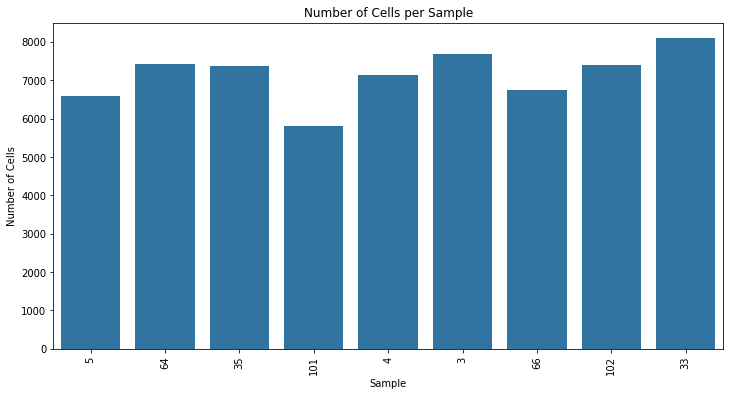

In [16]:
sample_counts = combined_adata.obs['Sample'].value_counts()

# Convert to DataFrame for easier plotting
sample_counts_df = sample_counts.reset_index()
sample_counts_df.columns = ['Sample', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=sample_counts_df, x='Sample', y='Cell Count')
plt.xlabel('Sample')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per Sample')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

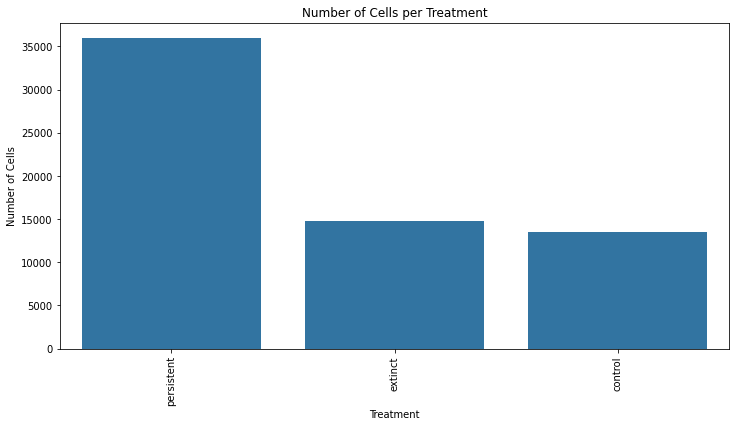

In [17]:
Treatment_counts = combined_adata.obs['Treatment'].value_counts()

# Convert to DataFrame for easier plotting
Treatment_counts_df = Treatment_counts.reset_index()
Treatment_counts_df.columns = ['Treatment', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=Treatment_counts_df, x='Treatment', y='Cell Count')
plt.xlabel('Treatment')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per Treatment')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

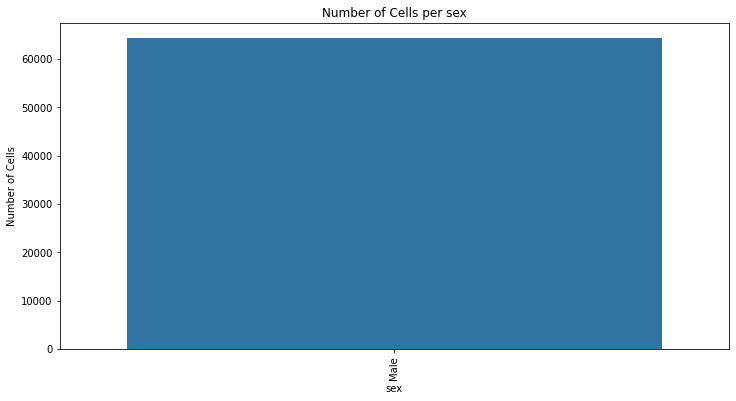

In [18]:
sex_counts = combined_adata.obs['Sex'].value_counts()

# Convert to DataFrame for easier plotting
sex_counts_df = sex_counts.reset_index()
sex_counts_df.columns = ['sex', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=sex_counts_df, x='sex', y='Cell Count')
plt.xlabel('sex')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per sex')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

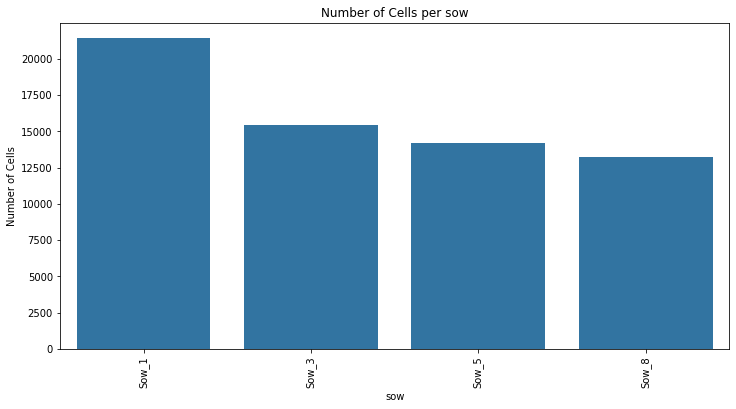

In [19]:
sow_counts = combined_adata.obs['Sow'].value_counts()

# Convert to DataFrame for easier plotting
sow_counts_df = sow_counts.reset_index()
sow_counts_df.columns = ['sow', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=sow_counts_df, x='sow', y='Cell Count')
plt.xlabel('sow')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per sow')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

In [20]:
###QC steps###
qc_data = combined_adata.obs.copy()

In [21]:
qc_data

,Sample,Timepoint,Treatment,Sex,Sow,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
TTGGGTACAGACGGAT-1-5,5,14_dpi,persistent,Male,Sow_1,7943,93290.0,6260.0,6.710258
AACCAACTCTATACGG-1-5,5,14_dpi,persistent,Male,Sow_1,7386,89912.0,4231.0,4.705712
AATTCCTAGTCAGCCC-1-5,5,14_dpi,persistent,Male,Sow_1,7390,80588.0,2535.0,3.145630
AAGCGTTTCTTGCGCT-1-5,5,14_dpi,persistent,Male,Sow_1,6892,76181.0,4696.0,6.164267
TTGGATGCAGATACCT-1-5,5,14_dpi,persistent,Male,Sow_1,7432,72691.0,3626.0,4.988238
...,...,...,...,...,...,...,...,...,...
ATAGGCTAGAGCAGCT-1-33,33,14_dpi,persistent,Male,Sow_3,12,137.0,132.0,96.350365
TCCGATCAGAGGATGA-1-33,33,14_dpi,persistent,Male,Sow_3,13,114.0,107.0,93.859650
CAGGCCAGTGTGTCCG-1-33,33,14_dpi,persistent,Male,Sow_3,12,124.0,117.0,94.354836
AGAGAATCAGTGTATC-1-33,33,14_dpi,persistent,Male,Sow_3,11,107.0,102.0,95.327103


/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/3017116752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/3017116752.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/3017116752.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



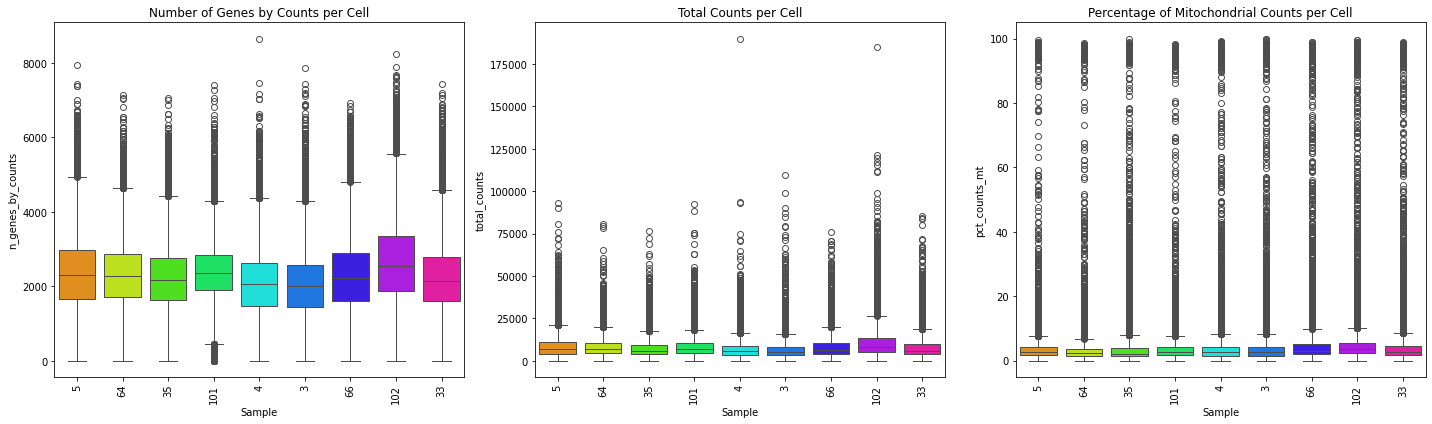

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_qc_parameters(qc_data):
    # Get unique samples and define a color palette
    samples = qc_data['Sample'].unique()
    num_samples = len(samples)
    palette = sns.color_palette("hsv", num_samples)  # Color palette with a distinct color for each sample
    
    plt.figure(figsize=(20, 6))

    # Plot n_genes_by_counts
    plt.subplot(1, 3, 1)
    sns.boxplot(data=qc_data, x='Sample', y='n_genes_by_counts', palette=palette)
    plt.title('Number of Genes by Counts per Cell')
    plt.xticks(rotation=90)

    # Plot total_counts
    plt.subplot(1, 3, 2)
    sns.boxplot(data=qc_data, x='Sample', y='total_counts', palette=palette)
    plt.title('Total Counts per Cell')
    plt.xticks(rotation=90)

    # Plot pct_counts_mt
    plt.subplot(1, 3, 3)
    sns.boxplot(data=qc_data, x='Sample', y='pct_counts_mt', palette=palette)
    plt.title('Percentage of Mitochondrial Counts per Cell')
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

# Call the function to plot the QC parameters
plot_qc_parameters(qc_data)


/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/228206168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/228206168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/228206168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



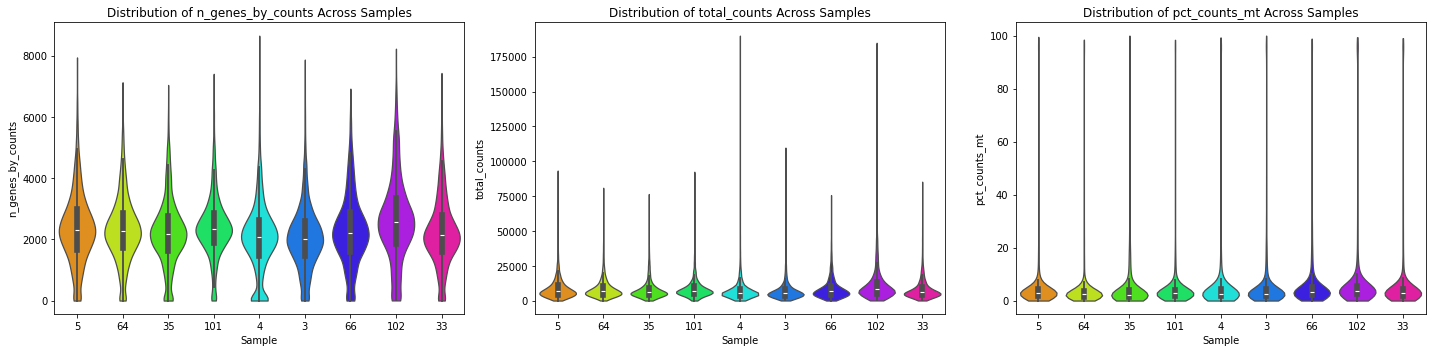

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_violin_plots(qc_data, metrics):
    samples = qc_data['Sample'].unique()
    num_samples = len(samples)
    num_metrics = len(metrics)
    num_cols = 3  
    num_rows = (num_metrics + num_cols - 1) // num_cols
    
    # Define a color palette with a distinct color for each sample
    palette = sns.color_palette("hsv", num_samples)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
    axes = axes.flatten()  # Flatten to easily index them
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        # Use seaborn's violinplot to plot each metric, with colors defined by the palette
        sns.violinplot(x='Sample', y=metric, data=qc_data, ax=ax, palette=palette, cut=0)
        ax.set_title(f'Distribution of {metric} Across Samples')
        ax.set_xlabel('Sample')
        ax.set_ylabel(metric)
    
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

# List of QC metrics to plot
metrics = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']
plot_violin_plots(qc_data, metrics)


/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/1750450072.py:11: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 2094 rows containing non-finite values.
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 18 rows containing missing values.


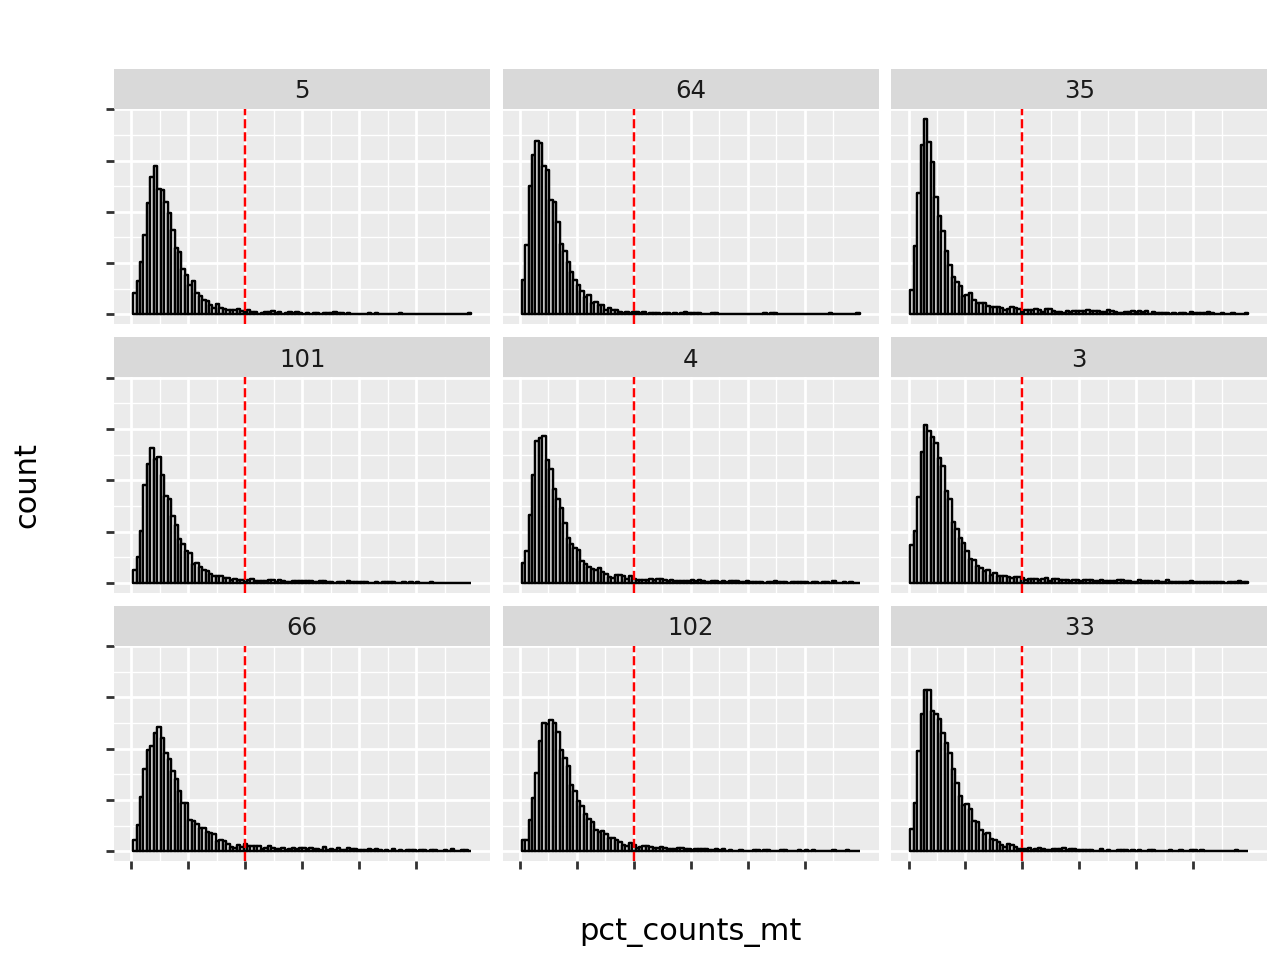

/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/1750450072.py:23: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 38818 rows containing non-finite values.
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 29 rows containing missing values.


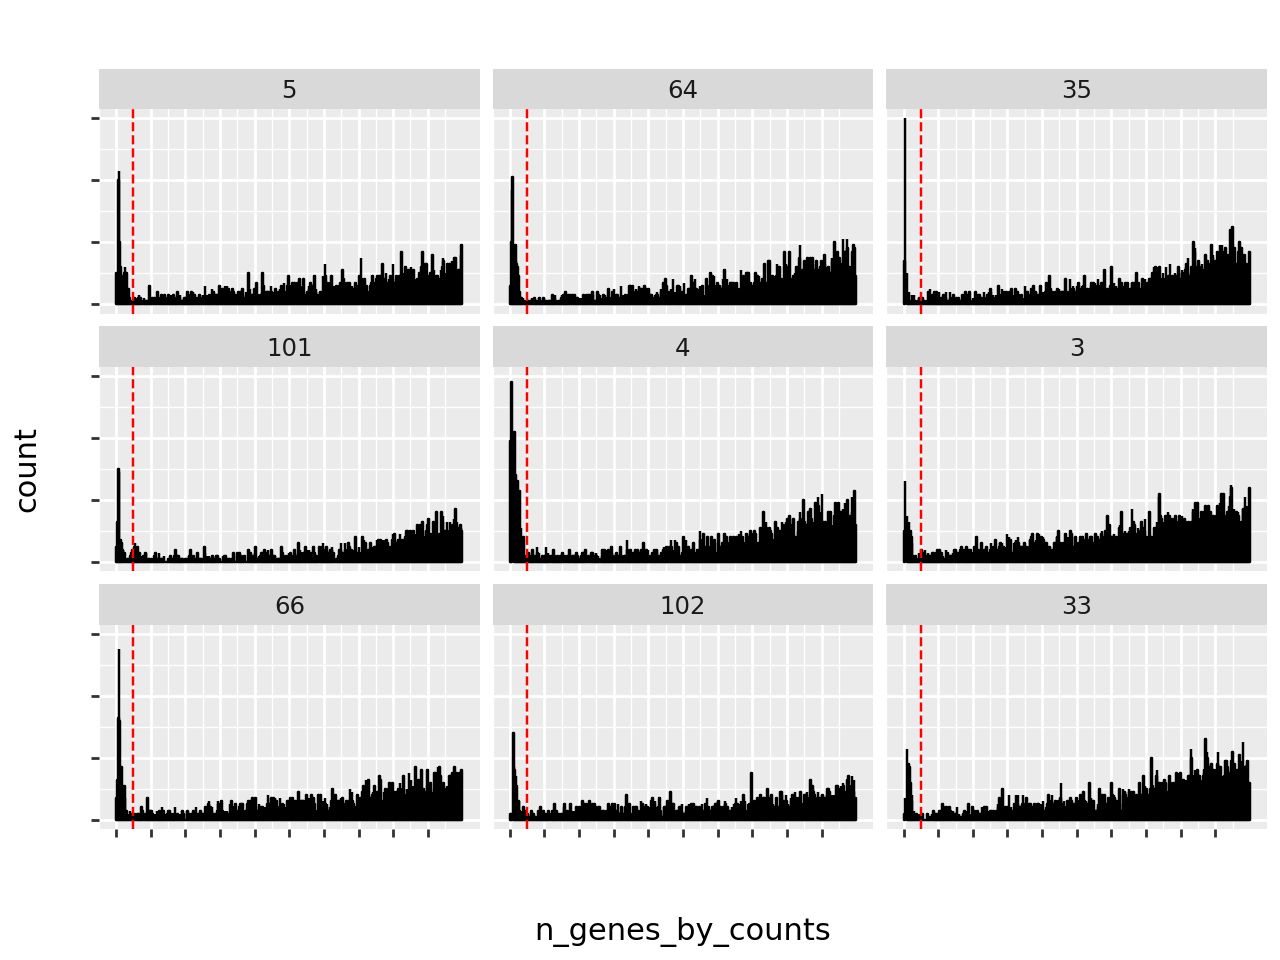

/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/1750450072.py:34: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 41473 rows containing non-finite values.
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 18 rows containing missing values.


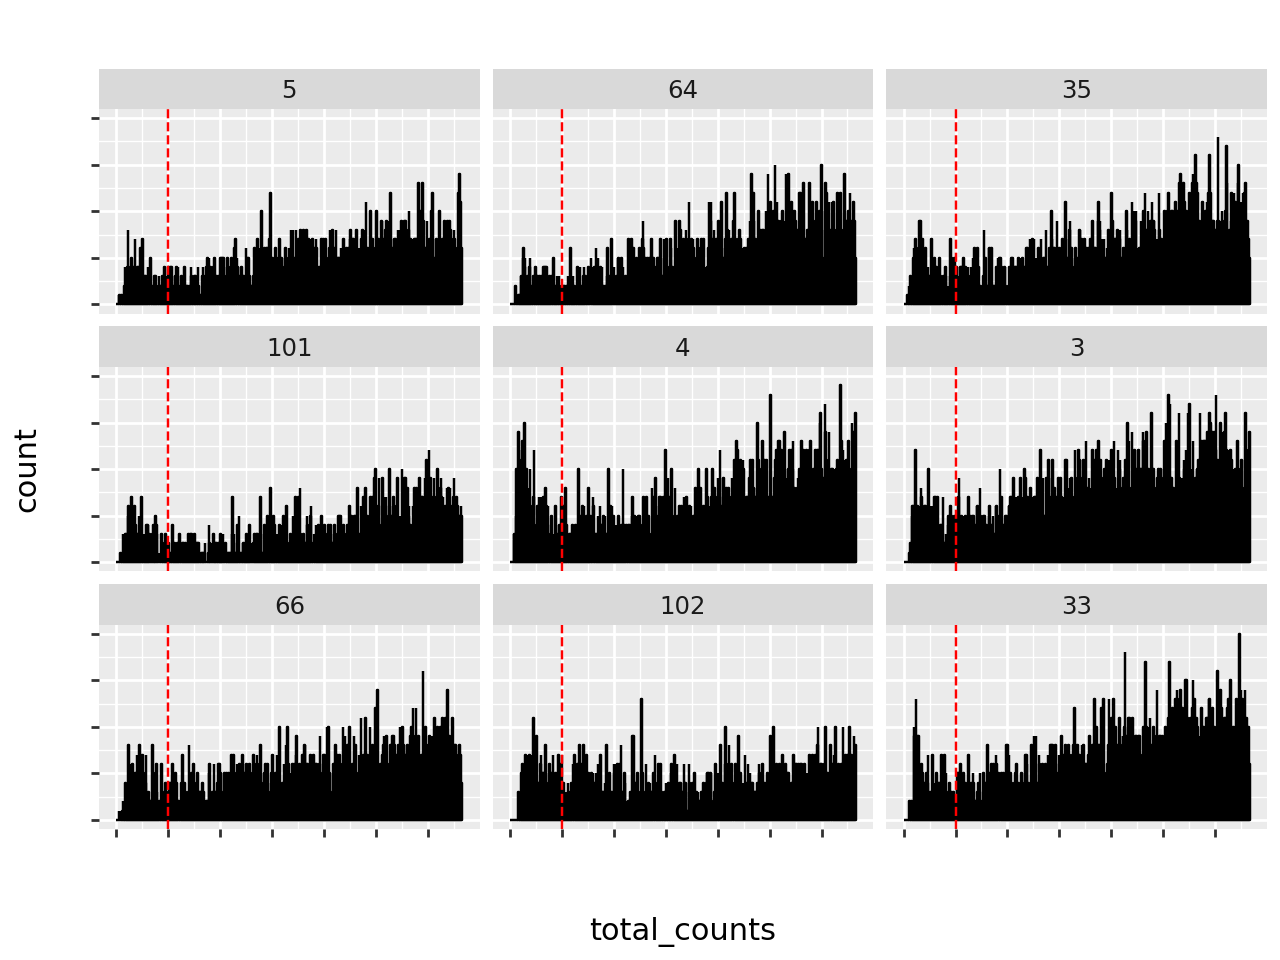

In [25]:
def plot_data(df):
    # Percent Mitochondrial Reads Plot
    p1 = (ggplot(df, aes(x='pct_counts_mt'))
          + geom_histogram(fill="white", color="black", bins=100)
          + scale_x_continuous(breaks=range(0, 30, 5), limits=(0, 30))
          + facet_wrap('~Sample')
          + geom_vline(aes(xintercept=10), color="red", linetype="dashed")
          + theme(axis_text_x=element_text(angle=90,color ='white') , axis_text_y=element_text(color='white'),plot_title=element_text(color='white', size=16))
          + labs(title ="Percent Mitochondrial Reads"))

    print(p1)

    # Genes Detected Plot
    p2 = (ggplot(df, aes(x='n_genes_by_counts'))
          + geom_histogram(fill="white", color="black", bins=500)
          + scale_x_continuous(breaks=range(0, 2000, 200), limits=(0, 2000))
          + ylim(0, 60)
          + facet_wrap('~Sample')
          + geom_vline(aes(xintercept=100), color="red", linetype="dashed")
          + theme(axis_text_x=element_text(angle=90,color ='white') , axis_text_y=element_text(color='white'),plot_title=element_text(color='white', size=16))
          + labs(title ="Genes Detected"))

    print(p2)

    # UMI Sums Plot
    p3 = (ggplot(df, aes(x='total_counts'))
          + geom_histogram(fill="white", color="black", bins=500)
          + scale_x_continuous(breaks=range(0, 5000, 750), limits=(0, 5000))
          + facet_wrap('~Sample')
          + geom_vline(aes(xintercept=750), color="red", linetype="dashed")
          + theme(axis_text_x=element_text(angle=90,color ='white') , axis_text_y=element_text(color='white'),plot_title=element_text(color='white', size=16))
          + labs(title ="UMI Sums"))

    print(p3)

plot_data(qc_data)

In [26]:
##Filtering threshold ####


def apply_quality_filters(df):
    # Adding QC metrics based on given data
    df['PassViability'] = df['pct_counts_mt'] < 10.0  
    df['PassGenesDet'] = df['n_genes_by_counts'] > 100
    df['PassLibSize'] = df['total_counts'] > 750

    # Combine all conditions to a single PassAll column
    df['PassAll'] = (df['PassViability'] & df['PassGenesDet'] & df['PassLibSize'])

    return df

In [27]:
qc_data =apply_quality_filters(qc_data)

In [28]:
qc_data

,Sample,Timepoint,Treatment,Sex,Sow,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,PassViability,PassGenesDet,PassLibSize,PassAll
TTGGGTACAGACGGAT-1-5,5,14_dpi,persistent,Male,Sow_1,7943,93290.0,6260.0,6.710258,True,True,True,True
AACCAACTCTATACGG-1-5,5,14_dpi,persistent,Male,Sow_1,7386,89912.0,4231.0,4.705712,True,True,True,True
AATTCCTAGTCAGCCC-1-5,5,14_dpi,persistent,Male,Sow_1,7390,80588.0,2535.0,3.145630,True,True,True,True
AAGCGTTTCTTGCGCT-1-5,5,14_dpi,persistent,Male,Sow_1,6892,76181.0,4696.0,6.164267,True,True,True,True
TTGGATGCAGATACCT-1-5,5,14_dpi,persistent,Male,Sow_1,7432,72691.0,3626.0,4.988238,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATAGGCTAGAGCAGCT-1-33,33,14_dpi,persistent,Male,Sow_3,12,137.0,132.0,96.350365,False,False,False,False
TCCGATCAGAGGATGA-1-33,33,14_dpi,persistent,Male,Sow_3,13,114.0,107.0,93.859650,False,False,False,False
CAGGCCAGTGTGTCCG-1-33,33,14_dpi,persistent,Male,Sow_3,12,124.0,117.0,94.354836,False,False,False,False
AGAGAATCAGTGTATC-1-33,33,14_dpi,persistent,Male,Sow_3,11,107.0,102.0,95.327103,False,False,False,False


In [29]:
combined_adata.obs.value_counts()

Sample  Timepoint  Treatment   Sex   Sow    n_genes_by_counts  total_counts  total_counts_mt  pct_counts_mt
35      14_dpi     extinct     Male  Sow_3  11                 5738.0        0.0              0.000000         2
33      14_dpi     persistent  Male  Sow_3  13                 178.0         173.0            97.191010        2
4       14_dpi     persistent  Male  Sow_1  3                  118.0         0.0              0.000000         2
                                            12                 124.0         120.0            96.774193        2
66      14_dpi     persistent  Male  Sow_5  1000               2256.0        71.0             3.147163         1
                                                                                                              ..
101     14_dpi     control     Male  Sow_8  14                 146.0         143.0            97.945206        1
                                                               166.0         161.0            96.9879

In [30]:
qc_data['PassAll'].value_counts()

True     56784
False     7457
Name: PassAll, dtype: int64

In [31]:
filtered_data = qc_data[qc_data['PassAll']]

In [32]:
combined_adata.obs = combined_adata.obs.join(filtered_data[['PassViability', 'PassGenesDet', 'PassLibSize', 'PassAll']], how='left')


In [33]:
combined_adata = combined_adata[combined_adata.obs['PassAll'] == True]

In [34]:
print(combined_adata.obs.dtypes)
print(combined_adata.var.dtypes)
combined_adata.obs['PassAll'] = combined_adata.obs['PassAll'].astype(str)
combined_adata.obs['PassViability'] = combined_adata.obs['PassViability'].astype(str)
combined_adata.obs['PassGenesDet'] = combined_adata.obs['PassGenesDet'].astype(str)
combined_adata.obs['PassLibSize'] = combined_adata.obs['PassLibSize'].astype(str)

Sample               category
Timepoint              object
Treatment              object
Sex                    object
Sow                    object
n_genes_by_counts       int32
total_counts          float32
total_counts_mt       float32
pct_counts_mt         float32
PassViability          object
PassGenesDet           object
PassLibSize            object
PassAll                object
dtype: object
gene_ids                  object
feature_types             object
genome                    object
EnsemblID                float64
Duplicated                  bool
Name                      object
Mitochondrial               bool
mt                          bool
n_cells_by_counts          int64
mean_counts              float32
pct_dropout_by_counts    float64
total_counts             float32
dtype: object


/mnt/job-temp/mkapoor/5342253/ipykernel_3816058/2413584124.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [35]:
combined_adata

AnnData object with n_obs × n_vars = 56784 × 25880
    obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'PassViability', 'PassGenesDet', 'PassLibSize', 'PassAll'
    var: 'gene_ids', 'feature_types', 'genome', 'EnsemblID', 'Duplicated', 'Name', 'Mitochondrial', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [36]:
os.chdir("/work/abg/mkapoor/Project_Fang_10X/14dpi_PRRSV/Project_Fang_10X/Project_Fang_10X")

In [37]:
combined_adata.write_h5ad('filtered_postQC_postcb_combined_adata_14dpi.h5ad')